In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df=pd.read_excel(r"C:\Users\user'\Desktop\OFFICE\Project\Project 1- Data Center\Data\Excel_Files\Global Datacenter Project.xlsx")
df

,Country,Total Data Center,Hyperscale Data Centers,Colocation Data Centers,Power Capacity Mw Total,Average Renewable Energy Usage Percent,Key Operators,Growth Rate Of Data Centers Percent Per Year,Cooling Technologies Common,Regulatory Challenges Or Limits,Disaster Recovery Sites Common,Green Dc Initiatives Description,Source Of Data
0,United States,5426,300+,"2,000+","12,000+",~27%,"Equinix, Digital Realty, CoreSite, AWS",0.12,"Air, Liquid, Immersion","Power grid strain in VA, moratoriums in some s...","Yes, especially for finance/health","Solar, wind PPA, immersion cooling, LEED","Statista, Brightlio, IEA, CBRE"
1,Germany,529,50,200,"2,000+",40%+,"Equinix, Digital Realty, e-shelter",0.08,"Air, Indirect Evap.","Power caps in Frankfurt, strict emissions","Yes, especially for finance","Wind, solar, carbon-neutral push","Statista, CBRE, IEA"
2,United Kingdom,523,30,150,"1,000+",0.45,"Equinix, Telehouse, Virtus",0.07,"Air, Free Cooling",Power grid constraints in London,"Yes, especially for finance","Wind, solar, carbon-neutral targets","Statista, CBRE, IEA"
3,China,449,100,"1,000+","8,000+",0.25,"China Unicom, Tencent, Alibaba, GDS",0.15,"Air, Liquid",Power rationing in some provinces,"Yes, for government/finance","Hydro, wind, solar, green finance","Statista, CBRE, IEA"
4,France,322,20,110,700,40%+,"Equinix, Interxion, Data4",0.06,"Air, Liquid",Power grid constraints in Paris,"Yes, for finance/health","Wind, solar, PUE targets","Statista, CBRE, IEA"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,Venezuela,6,0,6,20,44,"CANTV, Movistar, Digitel, Inter, NetUno, Super...",3,"Air cooling, UPS/gensets, precision AC in mode...","Grid collapse & hyperinflation, power blackout...",1 (modern DR-capable colo in Caracas),Submarine cables (GlobeNet landing at MaiquetÃ...,"DataReportal, Wikipedia, GlobeNet submarine op..."
187,Vietnam,32,1,32,145,80.7,"Viettel IDC, VNPT, FPT Telecom, CMC Telecom, V...",17.9,"Air cooling, precision CRAC/CRAH, UPS/gensets,...","Grid permitting delays, ruralâ€‘urban digital ...","3+ (Hanoi, Ho Chi Minh City, Da Nang)","Five submarine cables (APG, AAG, IA, SMW3/4), ...","DataReportal, Tuoi Tre, Arizton, ISOC Pulse, V..."
188,Yemen,1,0,1,0,45,No AWS/Azure/GCP region (cache/CDN labs only),0,"Air cooling, UPS/gensets, VSAT/Starlink backup...","Grid insecurity & airstrike risk, ISP monopoly...","AAEâ€‘1 cable landing at Aden, SEAâ€‘MEâ€‘WEâ€...",NaN,"DataReportal, ISOCâ€¯Pulse, Wikipedia, DataCen..."
189,Zambia,2,0,2,3,33,"Airtel Zambia, MTN Zambia, Zamtel, Liquid Tele...",6.29,"Air cooling, UPS/gensets, VSAT/Starlink fallba...","Grid cost & affordability, load shedding, ISP ...","0 (single edge sites, no formal DR)","EASSy via Mombasa terrestrial to Zambia, natio...","DataReportal, Statista, ISOC Pulse, Wikipedia,..."


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 13 columns):
 #   Column                                        Non-Null Count  Dtype 
---  ------                                        --------------  ----- 
 0   Country                                       191 non-null    object
 1   Total Data Center                             191 non-null    int64 
 2   Hyperscale Data Centers                       191 non-null    object
 3   Colocation Data Centers                       191 non-null    object
 4   Power Capacity Mw Total                       191 non-null    object
 5   Average Renewable Energy Usage Percent        191 non-null    object
 6   Key Operators                                 170 non-null    object
 7   Growth Rate Of Data Centers Percent Per Year  189 non-null    object
 8   Cooling Technologies Common                   190 non-null    object
 9   Regulatory Challenges Or Limits               191 non-null    object
 10  Di

In [5]:
df.isna().sum()

Country                                          0
Total Data Center                                0
Hyperscale Data Centers                          0
Colocation Data Centers                          0
Power Capacity Mw Total                          0
Average Renewable Energy Usage Percent           0
Key Operators                                   21
Growth Rate Of Data Centers Percent Per Year     2
Cooling Technologies Common                      1
Regulatory Challenges Or Limits                  0
Disaster Recovery Sites Common                  13
Green Dc Initiatives Description                26
Source Of Data                                   4
dtype: int64

In [6]:
# Rename the Heading

df=df.rename(
    columns={"Total Data Center":"Total_Datacenters",
            "Hyperscale Data Centers":"Hyperscale",
             "Colocation Data Centers":"Colocation",
             "Growth Rate Of Data Centers Percent Per Year":"Growth_Rate"
            })
# Remove unwanted Columns

df=df.drop(
    columns=["Power Capacity Mw Total",
             "Average Renewable Energy Usage Percent",
            "Key Operators",
             "Cooling Technologies Common",
             "Regulatory Challenges Or Limits",
             "Disaster Recovery Sites Common",
             "Green Dc Initiatives Description",
             "Source Of Data",
             "Colocation"
        
            ])
# Remove special characters

df["Total_Datacenters"] = (
    df["Total_Datacenters"]
    .fillna("")
    .astype(str)
    .str.replace(r"[^A-Za-z0-9 ]", "", regex=True)
)

df["Hyperscale"] = (
    df["Hyperscale"]
    .fillna("")
    .astype(str)
    .str.replace(r"[^A-Za-z0-9 ]", "", regex=True)
)
df['Total_Datacenters'] = pd.to_numeric(df['Total_Datacenters'], errors='coerce')
df['Hyperscale'] = pd.to_numeric(df['Hyperscale'], errors='coerce')
df['colocation'] = df['Total_Datacenters'] - df['Hyperscale']
df['Growth_Rate'] = pd.to_numeric(df['Growth_Rate'], errors='coerce')
df=df.drop_duplicates()  # Remove Duplicates 
df=df.fillna("0")
df.index = range(1, len(df) + 1)  # Start count from "1"
df

,Country,Total_Datacenters,Hyperscale,Growth_Rate,colocation
1,United States,5426,300,0.12,5126
2,Germany,529,50,0.08,479
3,United Kingdom,523,30,0.07,493
4,China,449,100,0.15,349
5,France,322,20,0.06,302
...,...,...,...,...,...
187,Venezuela,6,0,3.0,6
188,Vietnam,32,1,17.9,31
189,Yemen,1,0,0.0,1
190,Zambia,2,0,6.29,2


In [15]:
df.isnull().sum()

Country              0
Total_Datacenters    0
Hyperscale           0
Growth_Rate          0
colocation           0
dtype: int64

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191 entries, 1 to 191
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Country            191 non-null    object
 1   Total_Datacenters  191 non-null    int64 
 2   Hyperscale         191 non-null    int64 
 3   Growth_Rate        191 non-null    object
 4   colocation         191 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 7.6+ KB


## Variables for Visualisation

In [8]:
d1=df["Total_Datacenters"].sum()
d2=df["Hyperscale"].sum()
d3=df["colocation"].sum()
types=["Total DataCenter","Hyperscale","Colocation"]
topfive=df.head()
years = list(range(2000, 2026, 5))

# Visualization


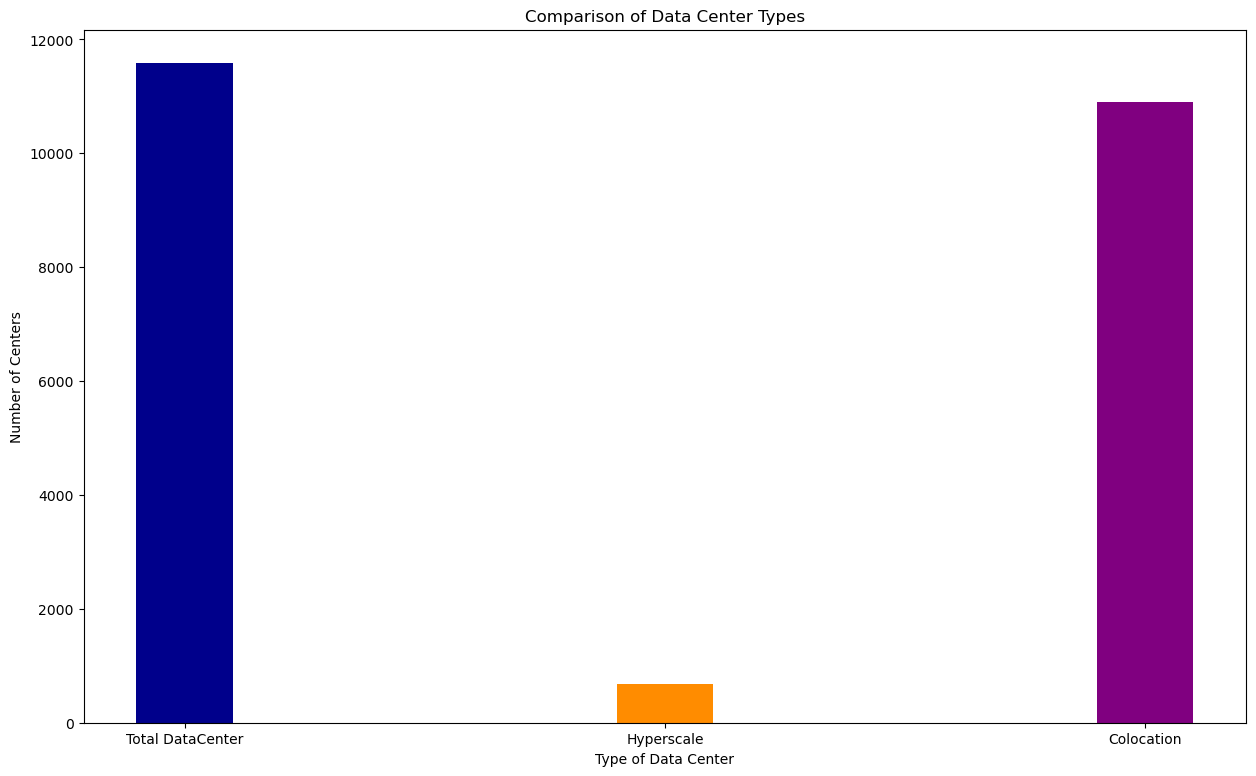

In [9]:
counts = [d1, d2, d3]
types = ["Total DataCenter", "Hyperscale", "Colocation"]


# Create the plot
plt.figure(figsize=(15,9))
plt.bar(types, counts, width=0.2,color=['darkblue', 'darkorange','purple'])

plt.xlabel("Type of Data Center")
plt.ylabel('Number of Centers')
plt.title('Comparison of Data Center Types')
plt.show()

# Top 20 Countries 

In [10]:
## Total Datacenters by ountries 

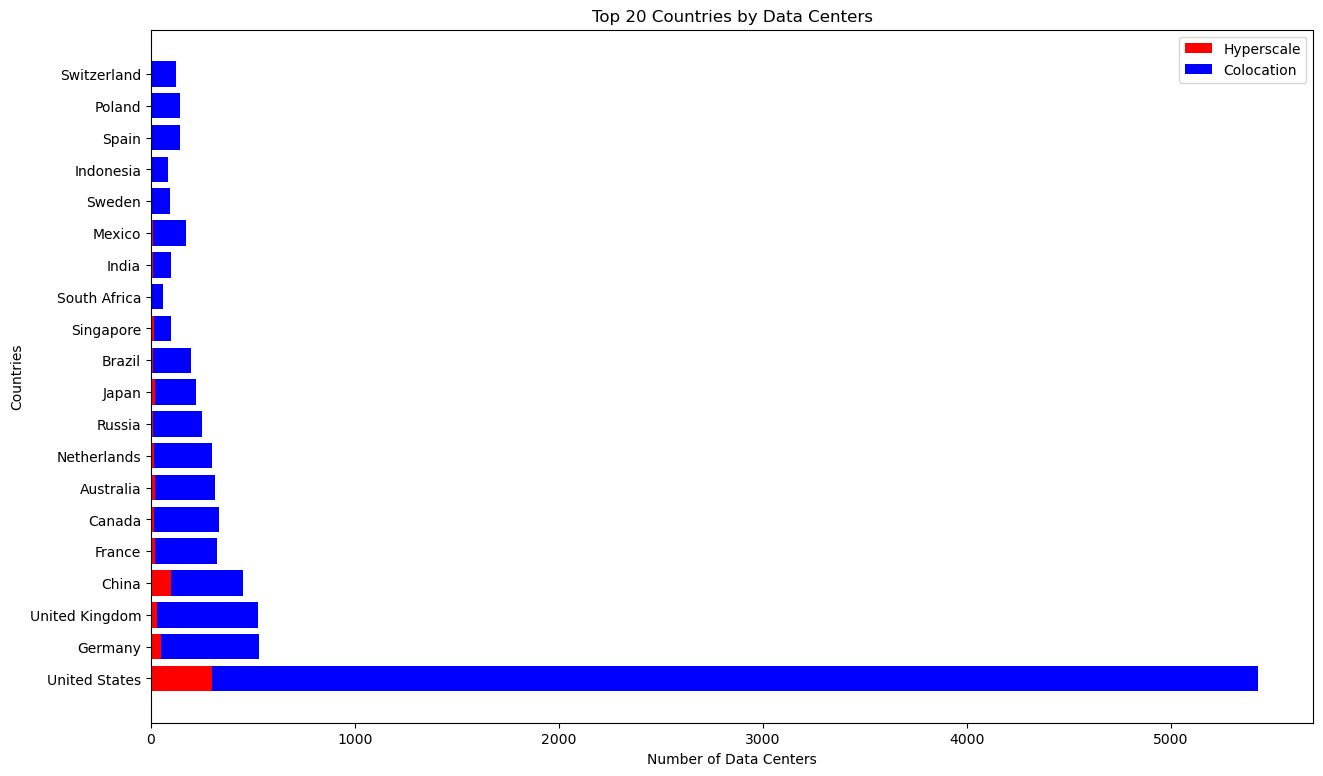

In [11]:
top20=df.head(20)
countries20=(df["Country"]).head(20)
hyperscale20=(df["Hyperscale"]).head(20)
colocation20=(df["colocation"]).head(20)
total=(hyperscale20)+(colocation20)
plt.figure(figsize=(15,9))

plt.barh(countries20, hyperscale20, color="red", label="Hyperscale")
plt.barh(countries20, colocation20, left=hyperscale20, color="blue", label="Colocation")

plt.xlabel("Number of Data Centers")
plt.ylabel("Countries")
plt.title("Top 20 Countries by Data Centers")
plt.legend()
plt.show()

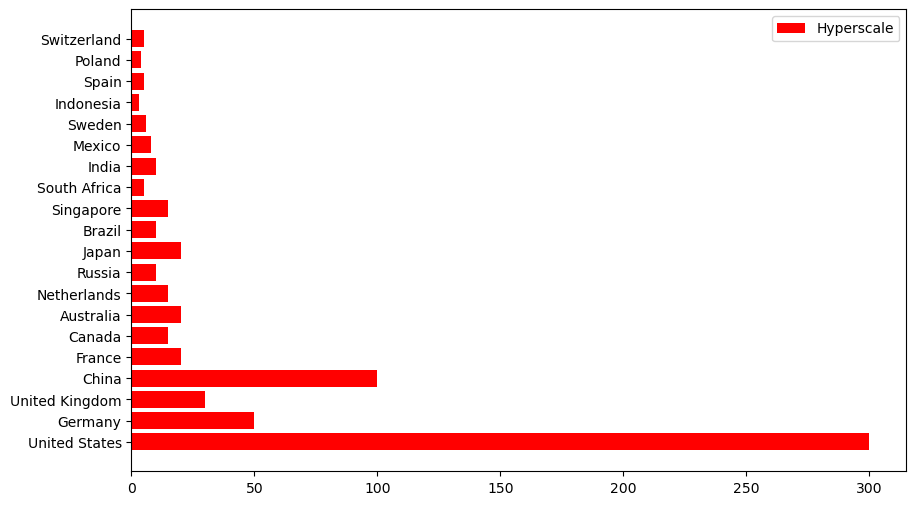

In [12]:

plt.figure(figsize=(10,6))
plt.barh(countries20, hyperscale20, color="red", label="Hyperscale")
plt.legend()
plt.show()

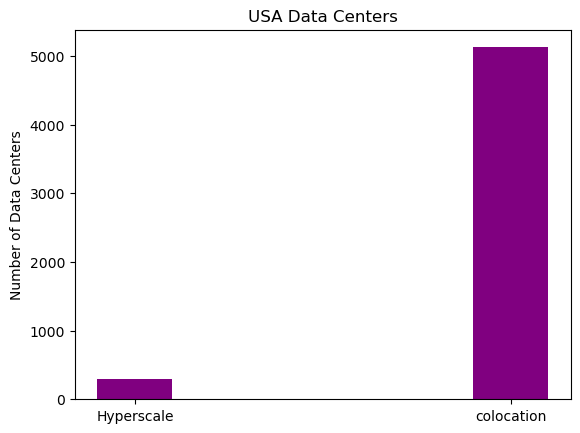

In [13]:
usa = df.loc[df["Country"] == "United States",
             ["Hyperscale", "colocation"]]

x = usa.columns.tolist()
y = usa.iloc[0].values.tolist()

plt.bar(x, y,width=0.2,color="purple")
plt.ylabel("Number of Data Centers")
plt.title("USA Data Centers")
plt.show()
